In [15]:
import urllib.request
urllib.request.urlretrieve("https://raw.githubusercontent.com/nshaud/ml_for_astro/main/stars.csv", "stars.csv")

('stars.csv', <http.client.HTTPMessage at 0x1e5e4fe22c0>)

In [16]:
import pandas as pd
df_stars = pd.read_csv("stars.csv")

In [17]:
df_stars

,Temperature (K),Luminosity(L/Lo),Radius(R/Ro),Absolute magnitude(Mv),Star type,Star color,Spectral Class
0,3068,0.002400,0.1700,16.12,Brown Dwarf,Red,M
1,3042,0.000500,0.1542,16.60,Brown Dwarf,Red,M
2,2600,0.000300,0.1020,18.70,Brown Dwarf,Red,M
3,2800,0.000200,0.1600,16.65,Brown Dwarf,Red,M
4,1939,0.000138,0.1030,20.06,Brown Dwarf,Red,M
...,...,...,...,...,...,...,...
235,38940,374830.000000,1356.0000,-9.93,Hypergiant,Blue,O
236,30839,834042.000000,1194.0000,-10.63,Hypergiant,Blue,O
237,8829,537493.000000,1423.0000,-10.73,Hypergiant,White,A
238,9235,404940.000000,1112.0000,-11.23,Hypergiant,White,A


In [20]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()


df_stars['Star type encoded'] = le.fit_transform(df_stars['Star type'])
labels = le.inverse_transform(df_stars['Star type encoded'])
class_names = le.classes_

print(class_names)

['Brown Dwarf' 'Hypergiant' 'Main Sequence' 'Red Dwarf' 'Supergiant'
 'White Dwarf']


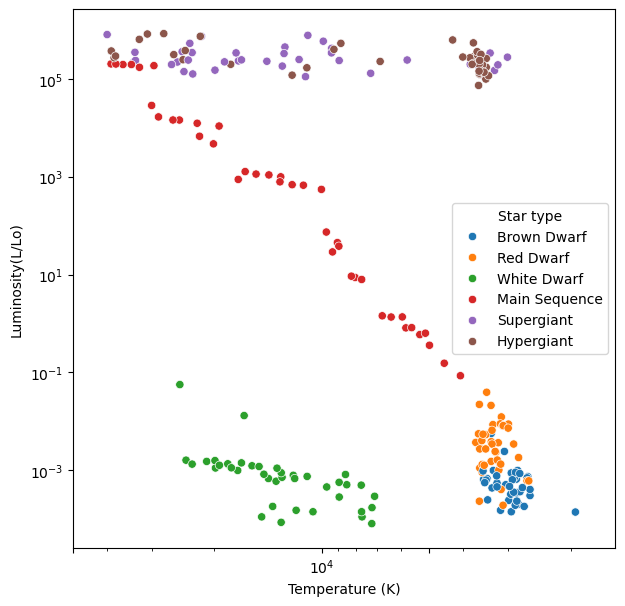

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(7,7))
sns.scatterplot(data=df_stars, x='Temperature (K)', y='Luminosity(L/Lo)', hue='Star type')

plt.xscale('log')
plt.yscale('log')
plt.xticks([5000, 10000, 50000])
plt.xlim(5e4, 1.5e3)
plt.show()

In [23]:
X = df_stars.select_dtypes(include=['int64', 'float64'])

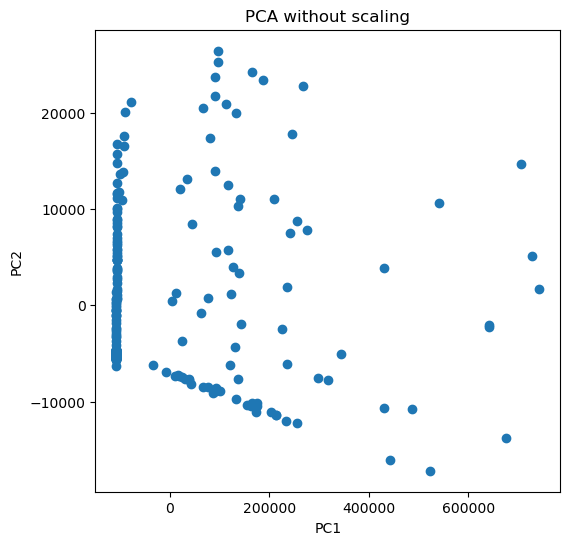

In [24]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.figure(figsize=(6,6))
plt.scatter(X_pca[:,0], X_pca[:,1])
plt.title('PCA without scaling')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.show()

In [25]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

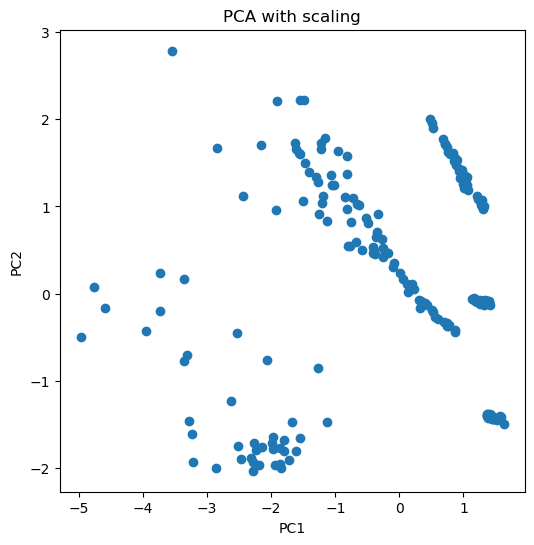

In [26]:
pca_scaled = PCA(n_components=2)
X_pca_scaled = pca_scaled.fit_transform(X_scaled)

plt.figure(figsize=(6,6))
plt.scatter(X_pca_scaled[:,0], X_pca_scaled[:,1])
plt.title('PCA with scaling')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.show()

In [28]:
print("Explained variance ratio:", pca_scaled.explained_variance_ratio_)
print("Total variance explained:", sum(pca_scaled.explained_variance_ratio_))

Explained variance ratio: [0.48394727 0.28274007]
Total variance explained: 0.766687342885638


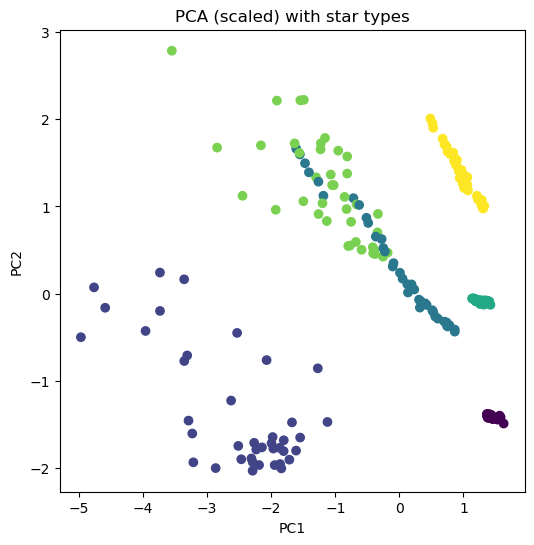

In [29]:
plt.figure(figsize=(6,6))
plt.scatter(
    X_pca_scaled[:, 0],
    X_pca_scaled[:, 1],
    c=pd.Categorical(df_stars['Star type']).codes
)
plt.title("PCA (scaled) with star types")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()